## 8 — Predict the SES-WOA components ("domains")

This script:
- Reuses the data preparation from script 7 (per-buurt per-cluster embeddings)
- Loads the **three SES-WOA component scores** (plus the overall total)
- For each component × (each cluster + global), trains an XGBoost model (cloned from best_model) using 5-fold CV
- Produces a results matrix (components × clusters+global) and a heatmap

**Why components rather than "domains".** SES-WOA is a single composite index built from three
constituent components, so — unlike multi-domain indices such as the UK IMD — it has no set of
separate deprivation domains to predict. We therefore predict the three genuine SES-WOA **components**:

| SES-WOA component (CBS) | column |
|---|---|
| financiële welvaart (financial wealth) | `ses_welvaart` |
| opleidingsniveau (education level) | `ses_opleiding` |
| arbeidsverleden (labour history) | `ses_arbeidsverleden` |

plus the overall SES-WOA total (`ses_woa_score`) as the comparison row.

**Limits of this decomposition.** Because the three are constituents of one composite index, they are
highly inter-correlated by construction (see the correlation heatmap below). This is a coarse,
component-level decomposition rather than a set of independent deprivation dimensions — interpret it
accordingly. See the README for discussion.

### Dependencies
**Prerequisites:** Scripts 4 and 5 (needs best model and cluster-assigned pickle).

**Inputs:**
- `data/processed/one_row_per_image_cleaned_with_cluster_numbers.pkl` — from script 5
- `data/models/best_model.joblib` — from script 4 (cloned for per-component models)
- CBS SES-WOA target (via `amsterdam_data.get_ses_woa()`) — total + three component scores
- `clustering_functions.py` — imports `global_k`, `RANDOM_STATE`, `embedding_statistic`, `agg_funcs`

**Outputs:**
- No saved files (results computed in memory); displays R² and NRMSE heatmaps

**Used by:** None (terminal analysis notebook)

In [1]:
import os
import numpy as np
import pandas as pd
from functools import reduce
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone  # clone lets us re-use the best model's architecture without leaking fitted state
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from joblib import Parallel, delayed

In [2]:
from directory_filepaths import *
from clustering_functions import global_k, RANDOM_STATE, embedding_statistic, mean_embed, median_embed, max_embed, agg_funcs
from amsterdam_data import get_ses_woa

# global_k is the number of clusters (set once in clustering_functions.py, used across all scripts)
print(f"Number of clusters (defined in clustering_functions.py) = {global_k}")
print(f"Using '{embedding_statistic}' embedding aggregation (from clustering_functions.py)")
k = global_k
statistic = embedding_statistic

Number of clusters (defined in clustering_functions.py) = 5
Using 'median' embedding aggregation (from clustering_functions.py)


### Load image data and compute per-buurt embeddings
Same approach as script 7.

In [3]:
# Load the expanded dataframe with cluster assignments (output of script 5).
# This has one row per image (~75k rows), each with a 512-dim CLIP embedding
# and a cluster label (e.g. scene_cluster_5 = 1..5).
expanded_gdf = pd.read_pickle(os.path.join(data_dir, "one_row_per_image_cleaned_with_cluster_numbers.pkl"))
print(f"Loaded {len(expanded_gdf)} image rows")

Loaded 200192 image rows


In [4]:
# The cluster column name depends on k (e.g. "scene_cluster_5" for k=5)
category_column = f"scene_cluster_{k}"
categories = sorted(expanded_gdf[category_column].unique())
print(f"Clusters: {categories}")

Clusters: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)]


In [5]:
# --- Aggregate image-level embeddings to per-buurt summaries ---
# For each buurt, we compute three summary statistics (mean, median, max)
# of the 512-dim embeddings, both:
#   (a) within each cluster separately (e.g. "1_median", "2_median", ...)
#   (b) across all images regardless of cluster ("overall_median")
# This gives us the feature vectors we'll use as model inputs.
#
# mean_embed, median_embed, max_embed, and agg_funcs are imported from clustering_functions.py

all_dfs = []
for agg_name, func in agg_funcs.items():
    dfs = []

    # Per-cluster: aggregate embeddings for images in each cluster within each buurt
    for cat in categories:
        emb_cat = (
            expanded_gdf[expanded_gdf[category_column] == cat]
            .groupby(JOIN_KEY)["embedding"]
            .apply(func)
            .reset_index()
            .rename(columns={"embedding": f"{cat}_{agg_name}"})
        )
        dfs.append(emb_cat)

    # Outer merge so buurten missing a cluster get NaN (handled later)
    # (reduce() cumulatively merges the dfs)
    merged = reduce(lambda left, right: pd.merge(left, right, on=JOIN_KEY, how="outer"), dfs)

    # Overall: aggregate across ALL images in the buurt (ignoring cluster)
    overall = (
        expanded_gdf.groupby(JOIN_KEY)["embedding"]
        .apply(func)
        .reset_index()
        .rename(columns={"embedding": f"overall_{agg_name}"})
    )
    merged = merged.merge(overall, on=JOIN_KEY, how="left")
    all_dfs.append(merged)

# Combine mean, max, and median into a single wide DataFrame
# Result: one row per buurt, columns like "1_mean", "1_median", ..., "overall_median", etc.
embedding_df = reduce(lambda left, right: pd.merge(left, right, on=JOIN_KEY, how="outer"), all_dfs)
print(f"{len(embedding_df)} buurten, {len(embedding_df.columns) - 1} embedding columns")

641 buurten, 18 embedding columns


In [6]:
embedding_df

,buurtcode,1_mean,2_mean,3_mean,4_mean,5_mean,overall_mean,1_median,2_median,3_median,4_median,5_median,overall_median,1_max,2_max,3_max,4_max,5_max,overall_max
0,BU00340101,"[-0.027706321, -0.030496486, 0.0019078605, -0....","[-0.030258179, 0.0021065872, -0.0051822662, -0...","[-0.021725202, 0.0011579111, 0.0055954834, -0....",NaN,"[-0.029514754, -0.018330203, 0.004145163, -0.0...","[-0.027648471, -0.021078277, 0.0030856994, -0....","[-0.029418945, -0.030685425, 0.0020041466, -0....","[-0.04888916, -0.00043225288, -0.0046920776, 0...","[-0.02218628, 0.00182724, 0.0042533875, -0.001...",NaN,"[-0.028495789, -0.016937256, 0.003312111, -0.0...","[-0.028251648, -0.019752502, 0.0028305054, -0....","[0.007217407, 0.0029964447, 0.033325195, 0.020...","[0.008651733, 0.014732361, -0.00217247, 0.0050...","[0.013015747, 0.0259552, 0.033599854, 0.040954...",NaN,"[0.013389587, 0.013519287, 0.05947876, 0.02346...","[0.013389587, 0.0259552, 0.05947876, 0.0409545..."
1,BU00340102,"[-0.035787582, -0.027749728, 0.0031781055, -0....","[-0.021429276, -0.004095091, -0.004490663, -0....","[-0.03234896, -0.0028801728, -0.005438439, -0....","[0.0087916255, -0.032127142, -0.006943777, -0....","[-0.039748274, -0.021209298, 0.0036607094, -0....","[-0.029870199, -0.010559206, -0.0025551196, -0...","[-0.036193848, -0.026313782, 0.0047912598, -0....","[-0.020439148, -0.003961563, -0.00551033, -0.0...","[-0.03250122, -0.002793312, -0.005666733, -0.0...","[0.013660431, -0.041503906, -0.0059490204, -0....","[-0.039520264, -0.020309448, 0.0024051666, -0....","[-0.0308609, -0.010284424, -0.0032224655, -0.0...","[0.0044898987, 0.0015325546, 0.034240723, 0.02...","[0.026565552, 0.03414917, 0.024230957, 0.04165...","[0.020217896, 0.04446411, 0.038848877, 0.03289...","[0.04171753, 0.011909485, 0.013572693, 0.01081...","[0.0019054413, 0.02041626, 0.042755127, 0.0354...","[0.04171753, 0.04446411, 0.042755127, 0.041656..."
2,BU00340201,"[-0.029438019, 0.0008239746, -0.014606476, -0....","[-0.025578186, 0.011439226, -0.0066601755, 0.0...","[-0.033193, 0.010581815, -0.00078455417, 0.000...","[-0.0046920776, -0.015945435, 0.018463135, -0....","[-0.032664426, -0.005321463, 0.004897249, -0.0...","[-0.030262878, 0.0055563934, -0.0011552395, -0...","[-0.030204773, -0.0018692017, -0.013088226, -0...","[-0.025817871, 0.012065887, -0.005334854, 0.00...","[-0.033050537, 0.011047363, -0.0009126663, 0.0...","[-0.0046920776, -0.015945435, 0.018463135, -0....","[-0.032714844, -0.007724762, 0.00554657, -0.01...","[-0.030174255, 0.005525589, -0.0005005598, 0.0...","[-0.016967773, 0.028564453, -0.0051193237, 0.0...","[0.0039405823, 0.04510498, 0.025436401, 0.0466...","[0.0014896393, 0.052642822, 0.02796936, 0.0374...","[-0.0046920776, -0.015945435, 0.018463135, -0....","[0.006580353, 0.042877197, 0.037872314, 0.0397...","[0.006580353, 0.052642822, 0.037872314, 0.0466..."
3,BU00340202,"[-0.050008137, -0.008786519, 0.0039952598, -0....","[-0.036654938, 0.012794201, -0.009484046, 0.00...","[-0.037161883, 0.008457315, -0.00050220574, -0...",NaN,"[-0.039771676, -0.0019200966, 0.013047207, -0....","[-0.038217533, 0.0053507965, 0.0025112205, -0....","[-0.055908203, -0.004875183, 0.014076233, 0.00...","[-0.038604736, 0.012069702, -0.008666992, 0.00...","[-0.03878784, 0.0071849823, -0.0008275509, -0....",NaN,"[-0.04095459, -0.0023326874, 0.014087677, -0.0...","[-0.039886475, 0.0051193237, 0.001455307, -0.0...","[-0.022338867, 0.010192871, 0.020065308, 0.017...","[-0.006652832, 0.04534912, 0.013725281, 0.0328...","[-0.0011978149, 0.04373169, 0.03829956, 0.0292...",NaN,"[-0.008636475, 0.042938232, 0.035705566, 0.020...","[-0.0011978149, 0.04534912, 0.03829956, 0.0328..."
4,BU00340203,NaN,"[-0.022058487, 0.014703751, 0.007824898, -0.00...","[-0.03382778, 0.004816413, -0.0008838177, -0.0...",NaN,"[-0.036382936, -0.008246616, 0.010733404, -0.0...","[-0.03484887, -0.0035464615, 0.007647317, -0.0...",NaN,"[-0.017047882, 0.013561249, 0.009443283, -0.00...","[-0.034820557, 0.005220413, -0.0022850037, -0

### Load SES-WOA component data

In [7]:
# Load the SES-WOA scores (total + three components) per buurt
ses = get_ses_woa()

# Map display names -> column names. These are the three genuine SES-WOA components,
# (the three genuine SES-WOA components; see the note at the top).
# This dict is the single place to edit the set of "domains" predicted.
ses_components = {
    "Welvaart":          "ses_welvaart",        # financiele welvaart (financial wealth)
    "Opleidingsniveau":  "ses_opleiding",       # education level
    "Arbeidsverleden":   "ses_arbeidsverleden", # labour history
}

# Include the overall SES-WOA total as an extra row so we can compare component-level vs overall
ses_components["SES-WOA (overall)"] = "ses_woa_score"

# Keep only the columns we need (buurt code + one score column per component)
ses = ses[[JOIN_KEY] + list(ses_components.values())]

print(f"Loaded SES-WOA data for {len(ses)} buurten, {len(ses_components)} components")

Loaded SES-WOA data for 646 buurten, 4 components


In [8]:
# Inner merge: keep only buurten that have both embedding data and SES-WOA data
df = embedding_df.merge(ses, on=JOIN_KEY)
print(f"{len(df)} buurten after merge")

641 buurten after merge


### Correlation between SES-WOA components

Pearson correlation between the component score columns. Because these are constituent components of a
single composite index, they are expected to be strongly positively correlated (unlike the IMD's more
distinct domains).

Saved correlation heatmap to ../outputs/8-domain_correlation_heatmap.pdf


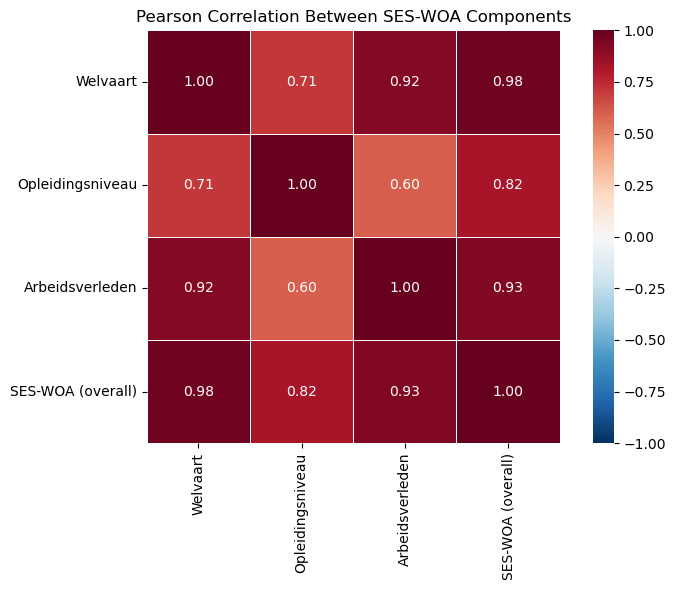

In [9]:
# Compute correlation matrix between component score columns
component_cols = list(ses_components.values())
component_short_names = list(ses_components.keys())

corr = df[component_cols].corr()
# Replace long column/index names with short names for readability
corr.index = component_short_names
corr.columns = component_short_names

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax,
)
ax.set_title("Pearson Correlation Between SES-WOA Components")
plt.tight_layout()

# Save to PDF in the outputs directory
output_path = os.path.join(outputs_dir, "8-domain_correlation_heatmap.pdf")
plt.savefig(output_path, bbox_inches="tight")
print(f"Saved correlation heatmap to {output_path}")

plt.show()

### Load best model

In [10]:
# Load the best model found in script 4 (a Pipeline: StandardScaler -> XGBRegressor).
# We'll clone() this for each (domain, cluster) combination so each model starts fresh.
best_model = joblib.load(os.path.join("../data/models/best_model.joblib"))['model']

### Train models: each domain × (each cluster + global)

For each domain, train a separate model for:
- Each cluster (using that cluster's median embedding; LSOAs without images in that cluster are dropped)
- Global (using the overall median embedding across all clusters; all LSOAs included)

#### 5-fold cross-validation

Each model is evaluated using **5-fold CV** (same as script 4), so every LSOA appears
in the test set exactly once. Results are reported as the mean across folds.

#### Why NRMSE?

Raw R² and RMSE are **not directly comparable** across clusters because each cluster model is 
evaluated on a different subset of LSOAs (different sizes, different deprivation distributions).

**Normalised RMSE** (NRMSE = RMSE / std(y_test)) removes this confound by expressing the 
prediction error relative to the target's spread in each test set. An NRMSE of 1.0 means the 
model is no better than predicting the mean; lower is better. Because NRMSE is unitless and 
scale-free, it can be compared across clusters and across domains.

In [11]:
# 5-fold CV (same as script 4)
N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def evaluate_one(X, y, best_model, kf):
    """Run k-fold CV for one (component, column) combination. Returns (mean_r2, mean_nrmse)."""
    r2_scores = []
    nrmse_scores = []
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = clone(best_model)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        r2_scores.append(r2_score(y_test, y_pred))
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        nrmse_scores.append(rmse / np.std(y_test))

    return np.mean(r2_scores), np.mean(nrmse_scores)

# Build list of jobs: one per (component, cluster/global) combination
jobs = []
job_keys = []  # (component_name, col_label) to reassemble results

for component_name, component_col in ses_components.items():
    # Per-cluster
    for cluster_num in categories:
        emb_col = f"{cluster_num}_{statistic}"
        subset = df[[JOIN_KEY, emb_col, component_col]].copy()
        has_embedding = subset[emb_col].apply(lambda x: not (isinstance(x, float) and np.isnan(x)))
        subset = subset[has_embedding].reset_index(drop=True)

        X = np.stack(subset[emb_col].values)
        y = subset[component_col].values

        jobs.append(delayed(evaluate_one)(X, y, best_model, kf))
        job_keys.append((component_name, f"Cluster {cluster_num}"))

    # Global
    emb_col_global = f"overall_{statistic}"
    X_global = np.stack(df[emb_col_global].values)
    y_global = df[component_col].values

    jobs.append(delayed(evaluate_one)(X_global, y_global, best_model, kf))
    job_keys.append((component_name, "Global"))

print(f"Running {len(jobs)} jobs ({N_SPLITS}-fold CV each) across all cores...")

# Run all jobs in parallel (-1 = use all cores)
results_list = Parallel(n_jobs=-2, verbose=1)(jobs)

# Reassemble into nested dict
all_results = {}
for (component_name, col_label), (r2_m, nrmse_m) in zip(job_keys, results_list):
    if component_name not in all_results:
        all_results[component_name] = {}
    all_results[component_name][col_label] = {
        "R2": r2_m,
        "NRMSE": nrmse_m,
    }

print(f"\nDone. {len(jobs)} jobs × {N_SPLITS} folds = {len(jobs) * N_SPLITS} total model fits.")

Running 24 jobs (5-fold CV each) across all cores...


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 11 concurrent workers.



Done. 24 jobs × 5 folds = 120 total model fits.


[Parallel(n_jobs=-2)]: Done 24 out of 24 | elapsed:    3.0s finished


### Results matrix

In [12]:
# Build results matrices for both metrics.
# Rows = IMD domains, Columns = clusters + Global.
cluster_cols = [f"Cluster {c}" for c in categories]
col_order = cluster_cols + ["Global"]

r2_matrix = pd.DataFrame(
    {domain: {col: metrics["R2"] for col, metrics in cols.items()}
     for domain, cols in all_results.items()}
).T[col_order]

nrmse_matrix = pd.DataFrame(
    {domain: {col: metrics["NRMSE"] for col, metrics in cols.items()}
     for domain, cols in all_results.items()}
).T[col_order]

print(f"R² (mean across {N_SPLITS}-fold CV):")
r2_matrix

R² (mean across 5-fold CV):


,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Global
Welvaart,0.311218,0.127502,0.224059,-0.049864,0.454326,0.442247
Opleidingsniveau,0.347088,0.191518,0.304952,0.040338,0.410065,0.427420
Arbeidsverleden,0.113369,0.081553,0.135505,-0.347737,0.249799,0.253334
SES-WOA (overall),0.329859,0.111990,0.211152,-0.102443,0.464257,0.473517


In [13]:
print(f"NRMSE (mean across {N_SPLITS}-fold CV):")
nrmse_matrix

NRMSE (mean across 5-fold CV):


,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Global
Welvaart,0.829053,0.931938,0.880674,1.024374,0.737880,0.745468
Opleidingsniveau,0.807337,0.898838,0.833289,0.978291,0.767405,0.755243
Arbeidsverleden,0.940670,0.957530,0.929206,1.154717,0.865412,0.863196
SES-WOA (overall),0.817407,0.940628,0.887980,1.049514,0.731241,0.724054


### Heatmap

Saved heatmap to ../outputs/8-domain_prediction_heatmap.pdf


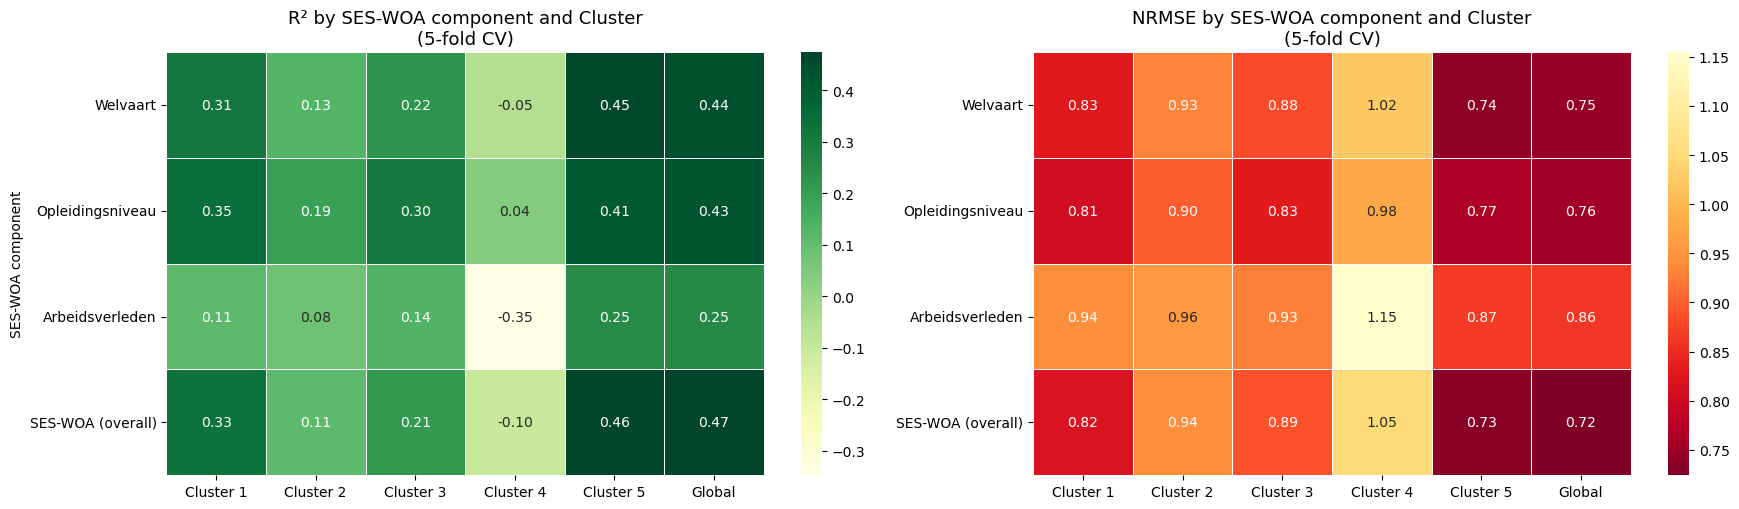

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(max(14, len(col_order) * 3), len(r2_matrix) * 0.8 + 2))

# --- Left: R² heatmap (higher = better) ---
sns.heatmap(
    r2_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGn",
    linewidths=0.5,
    ax=axes[0],
)
axes[0].set_title(f"R² by SES-WOA component and Cluster\n({N_SPLITS}-fold CV)", fontsize=13)
axes[0].set_ylabel("SES-WOA component")
axes[0].set_xlabel("")

# --- Right: NRMSE heatmap (lower = better) ---
sns.heatmap(
    nrmse_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd_r",
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title(f"NRMSE by SES-WOA component and Cluster\n({N_SPLITS}-fold CV)", fontsize=13)
axes[1].set_ylabel("")
axes[1].set_xlabel("")

plt.tight_layout()

# Save to PDF in the outputs directory (as well as displaying inline)
output_path = os.path.join(outputs_dir, "8-domain_prediction_heatmap.pdf")
plt.savefig(output_path, bbox_inches="tight")
print(f"Saved heatmap to {output_path}")

plt.show()